# Deep Soil Profile Properties Visualization

This notebook loads deep soil profile properties from `parameters_krycklan.py` and visualizes the saturated hydraulic conductivity ($K_{sat}$) as a function of depth for each soil type.

## 1. Set Paths and Import Libraries

In [10]:
import pathlib
import sys
import importlib.util

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define project paths
project_root = pathlib.Path.cwd().parent  # Go up one level from scripts folder
scripts_folder = project_root / 'scripts'

# Add parent directory to sys.path so we can import parameters_krycklan
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Scripts folder: {scripts_folder}")

Project root: /Users/jpnousu/Models/SpaFHy_v2.0
Scripts folder: /Users/jpnousu/Models/SpaFHy_v2.0/scripts


## 2. Load `deep_properties()` from `parameters_krycklan.py`

In [9]:
# Load the parameters_krycklan module
spec = importlib.util.spec_from_file_location(
    "parameters_krycklan", 
    project_root / "parameters_krycklan.py"
)
param_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(param_module)

# Get the deep_properties function and call it
deep_properties = param_module.deep_properties()

print(f"Number of soil types: {len(deep_properties)}")
print(f"Soil types: {list(deep_properties.keys())}")

Number of soil types: 11
Soil types: ['Postglacial_sand', 'Glaciofluvial_sediment', 'Peat', 'Postglacial_sand_gravel', 'Clay_silt', 'Washed_sediment_gravel_boulders', 'Water', 'Moraine', 'Fill', 'Bedrock', 'Fluvial_sediment_sand']


## 3. Convert Soil Dictionaries to Tabular Structure

In [3]:
# Convert to a long-format DataFrame for easier plotting
data = []

for soil_type, props in deep_properties.items():
    deep_z = props['deep_z']
    deep_ksat = props['deep_ksat']
    deep_id = props['deep_id']
    stream_ksat = props['stream_ksat']
    
    for layer_idx, (z, ksat) in enumerate(zip(deep_z, deep_ksat)):
        data.append({
            'soil_type': soil_type,
            'deep_id': deep_id,
            'layer_index': layer_idx,
            'deep_z': z,
            'deep_ksat': ksat,
            'stream_ksat': stream_ksat,
        })

df = pd.DataFrame(data)

print(f"Total data points: {len(df)}")
print("\nDataFrame head:")
print(df.head(10))

Total data points: 55

DataFrame head:
                soil_type  deep_id  layer_index  deep_z  deep_ksat  \
0        Postglacial_sand        1            0    -1.2     0.0001   
1        Postglacial_sand        1            1    -2.0     0.0001   
2        Postglacial_sand        1            2    -3.8     0.0001   
3        Postglacial_sand        1            3    -5.0     0.0001   
4        Postglacial_sand        1            4   -10.0     0.0001   
5  Glaciofluvial_sediment        2            0    -1.0     0.0001   
6  Glaciofluvial_sediment        2            1    -2.0     0.0001   
7  Glaciofluvial_sediment        2            2    -3.0     0.0001   
8  Glaciofluvial_sediment        2            3    -5.0     0.0001   
9  Glaciofluvial_sediment        2            4   -10.0     0.0001   

   stream_ksat  
0       0.0001  
1       0.0001  
2       0.0001  
3       0.0001  
4       0.0001  
5       0.0001  
6       0.0001  
7       0.0001  
8       0.0001  
9       0.0001  


## 4. Validate Profile Consistency

In [4]:
# Check data consistency
print("Validating profile consistency...\n")

issues = []
for soil_type, props in deep_properties.items():
    deep_z = props['deep_z']
    deep_ksat = props['deep_ksat']
    pF = props['pF']
    
    # Check list lengths
    if len(deep_z) != len(deep_ksat):
        issues.append(f"  {soil_type}: deep_z length ({len(deep_z)}) != deep_ksat length ({len(deep_ksat)})")
    
    # Check pF consistency
    pF_lengths = {k: len(v) for k, v in pF.items()}
    if not all(v == len(deep_z) for v in pF_lengths.values()):
        issues.append(f"  {soil_type}: pF arrays have inconsistent lengths: {pF_lengths}")

if issues:
    print("⚠ Issues found:")
    for issue in issues:
        print(issue)
else:
    print("✓ All profiles are consistent!")
    print(f"\nSummary by soil type:")
    for soil_type, props in deep_properties.items():
        n_layers = len(props['deep_z'])
        max_depth = min(props['deep_z'])  # Most negative value is deepest
        print(f"  {soil_type:35s}: {n_layers} layers, depth range: {max_depth:.1f} m")

Validating profile consistency...

✓ All profiles are consistent!

Summary by soil type:
  Postglacial_sand                   : 5 layers, depth range: -10.0 m
  Glaciofluvial_sediment             : 5 layers, depth range: -10.0 m
  Peat                               : 5 layers, depth range: -5.0 m
  Postglacial_sand_gravel            : 5 layers, depth range: -5.0 m
  Clay_silt                          : 5 layers, depth range: -10.0 m
  Washed_sediment_gravel_boulders    : 5 layers, depth range: -5.0 m
  Water                              : 5 layers, depth range: -5.0 m
  Moraine                            : 5 layers, depth range: -5.0 m
  Fill                               : 5 layers, depth range: -5.0 m
  Bedrock                            : 5 layers, depth range: -5.0 m
  Fluvial_sediment_sand              : 5 layers, depth range: -10.0 m


## 5. Plot `deep_ksat` Profiles by Soil Type vs Depth

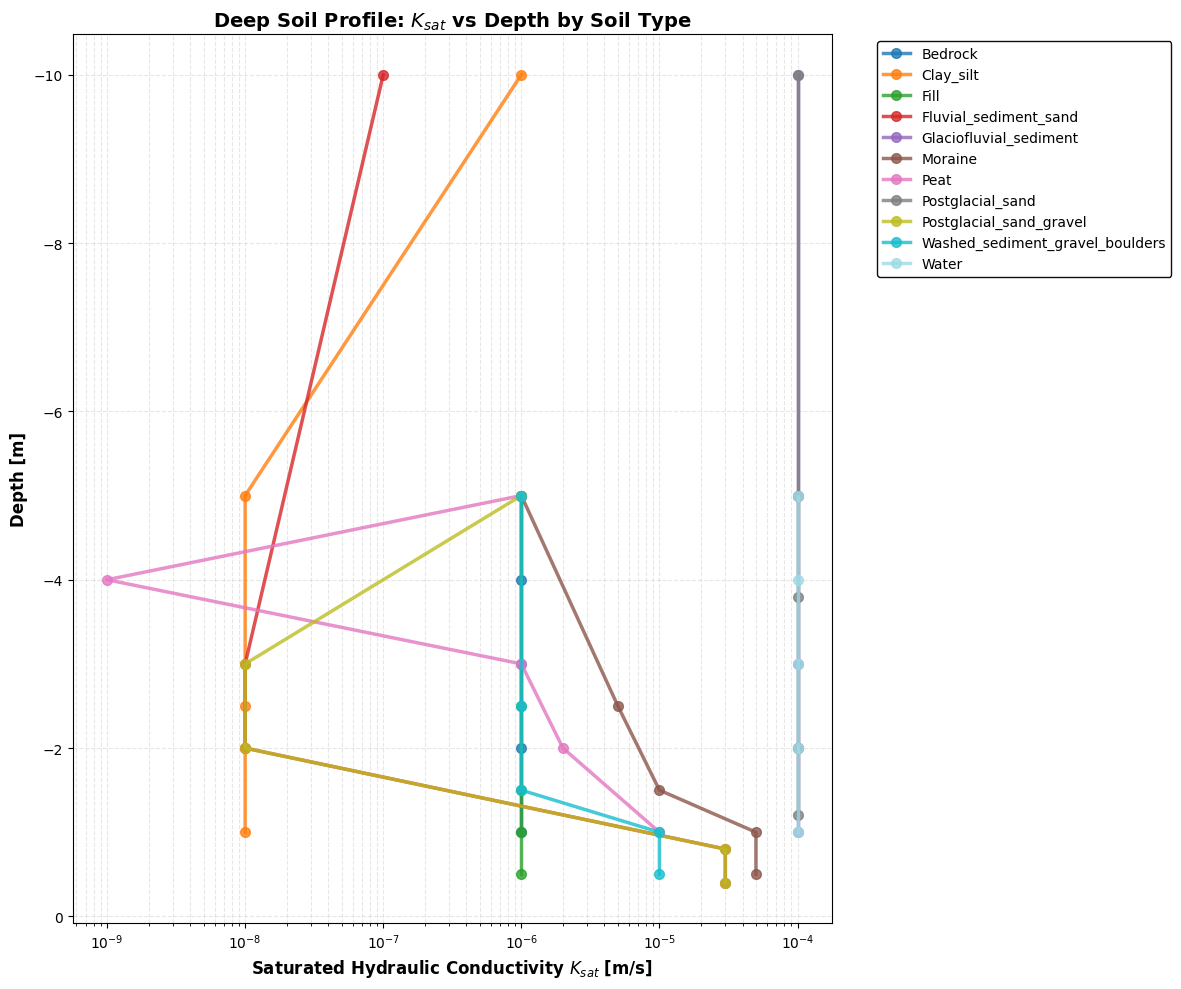

Plot generated successfully!


In [5]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Use a colormap for consistent colors across soil types
soil_types = sorted(deep_properties.keys())
colors = plt.cm.tab20(np.linspace(0, 1, len(soil_types)))

# Plot each soil type
for color, soil_type in zip(colors, soil_types):
    props = deep_properties[soil_type]
    deep_z = np.array(props['deep_z'])
    deep_ksat = np.array(props['deep_ksat'])
    
    # Sort by depth for proper line connection
    sort_idx = np.argsort(deep_z)
    z_sorted = deep_z[sort_idx]
    ksat_sorted = deep_ksat[sort_idx]
    
    # Plot profile line and markers
    ax.plot(ksat_sorted, z_sorted, marker='o', linewidth=2.5, markersize=7, 
            label=soil_type, color=color, alpha=0.8)

# Format axes
ax.set_xlabel('Saturated Hydraulic Conductivity $K_{sat}$ [m/s]', fontsize=12, fontweight='bold')
ax.set_ylabel('Depth [m]', fontsize=12, fontweight='bold')
ax.set_title('Deep Soil Profile: $K_{sat}$ vs Depth by Soil Type', fontsize=14, fontweight='bold')

# Set x-axis to log scale for better visualization
ax.set_xscale('log')

# Invert y-axis so deeper values appear lower
ax.invert_yaxis()

# Add grid
ax.grid(True, which='both', alpha=0.3, linestyle='--')

# Add legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, 
          framealpha=0.95, edgecolor='black')

plt.tight_layout()
plt.show()

print("Plot generated successfully!")